# Resolução do Case: Estágio em Dados Ismart
**Autor:** João Lucas de Lima Souza

Esta é a análise da base de dados referente à Prova Única (PU) de 2023, abrangendo os cadernos de Ciências Humanas (CH), Ciências da Natureza (CN), Matemática (MA) e Linguagens (LI).

### Preparação do Ambiente e Higienização de Dados
Nesta etapa inicial, foi feito o carregamento das bibliotecas necessárias e da base de dados bruta. 

Foi identificado a inconsistência na nomenclatura das cidades (ex: "SP", "SÃO PAULO" e "São Paulo"). Para garantir a precisão estatística e evitar a distorção dos resultados, foi aplicado um mapeamento de padronização, consolidando todas as entradas sob nomes únicos para cada praça de atuação.

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Carrega a base de dados
df = pd.read_excel("Base_Estag_Dados.xlsx", sheet_name='Base_Prova_Unica')

# Padronizando os nomes das Praças para evitar distorções
mapeamento_pracas = {
    'SÃO PAULO': 'SP', 
    'São Paulo': 'SP',
    'SP': 'SP',
    'Belo Horizonte': 'BH', 
    'BH': 'BH',
    'Rio de Janeiro': 'RJ', 
    'RJ': 'RJ'
}
# Cria uma nova coluna 'PRACA_LIMPA' com os nomes padronizados
df['PRACA_LIMPA'] = df['PRACA'].replace(mapeamento_pracas)

## Bloco 1: Estruturação da Base de Dados
O objetivo é construir uma base analítica onde cada aluno aparece uma única vez. 

**Observação:** Devido ao volume de dados (2.553 registros), este exbição apresenta apenas as primeiras linhas. O banco de dados completo e higienizado foi exportado automaticamente e está disponível no ficheiro **`Resultado_Bloco1_Ismart.xlsx`** anexo ao repositório no GitHub para visualização completa.

In [70]:
# Criando a tabela dinâmica com o pivot que mostra o ENEM Projetado para cada RA e Área
df_bloco1 = df.pivot_table(
    index=['RA', 'NOME COMPLETO'],             
    columns='ÁREA',        
    values='ENEM_Projetado',  
    aggfunc='max' # Caso o aluno tenha realizado mais de uma prova, por garantia, é recolhido a melhor nota projetada para cada área            
).reset_index()               

# Limpando o nome das colunas
df_bloco1.columns.name = None

# Salva todos os alunos em um arquivo Excel na pasta do projeto
df_bloco1.to_excel("Resultado_Bloco1_Ismart.xlsx", index=False)

# Conferência visual 
df_bloco1.head()

,RA,NOME COMPLETO,CH,CN,LI,MA
0,2545,ALINE,695.906615,657.264709,667.513141,728.627545
1,2547,BARBARA,680.436229,471.296044,655.513717,646.646025
2,2550,FRANCISCO,658.077029,618.081889,692.623383,763.575095
3,2551,GABRIEL,732.934631,682.165971,720.693663,736.060302
4,2553,GUILHERME,838.758293,870.382180,770.807568,776.047159


## Bloco 2: Análise de Desempenho e Correlação

### 1. Análise de Correlação entre as Notas
**Pergunta:** Há alguma correlação entre as três diferentes notas da Prova (NOTA DESEMPENHO, Media_ENEM e ENEM_Projetado)?

Para responder a esta questão, foi utilizado o **Coeficiente de Correlação de Pearson**. Esta é uma medida estatística que varia de -1 a +1 e indica o grau de relacionamento linear entre duas variáveis:

* **Próximo a +1:** Indica uma correlação positiva forte (quando uma nota sobe, a outra também sobe).
* **Próximo a 0:** Indica que não há relação entre as notas.


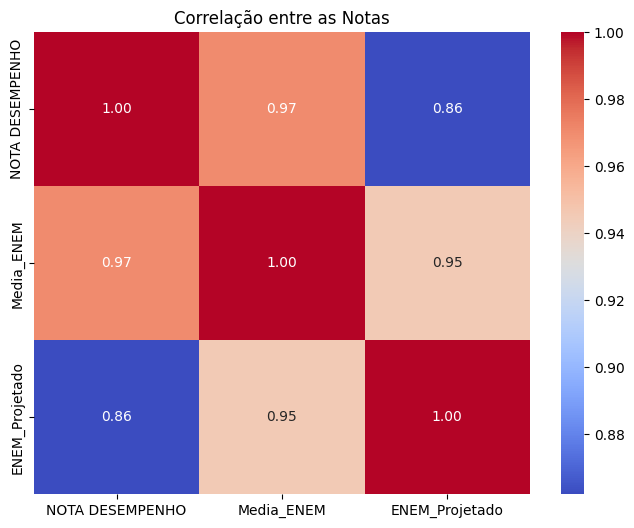

In [ ]:

colunas_notas = ['NOTA DESEMPENHO', 'Media_ENEM', 'ENEM_Projetado']
# Calcula a relação entre as notas 
matriz_correlacao = df[colunas_notas].corr() 

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre as Notas')
plt.show();

**Conclusão:** Observa-se uma **correlação positiva muito forte** (com valores chegando a 0.86) entre as três métricas. Isso indica que, embora as notas possuam escalas diferentes, elas apresentam alta consistência entre si.

---
### 2. Média de Enem Projetado por Praça (2023)


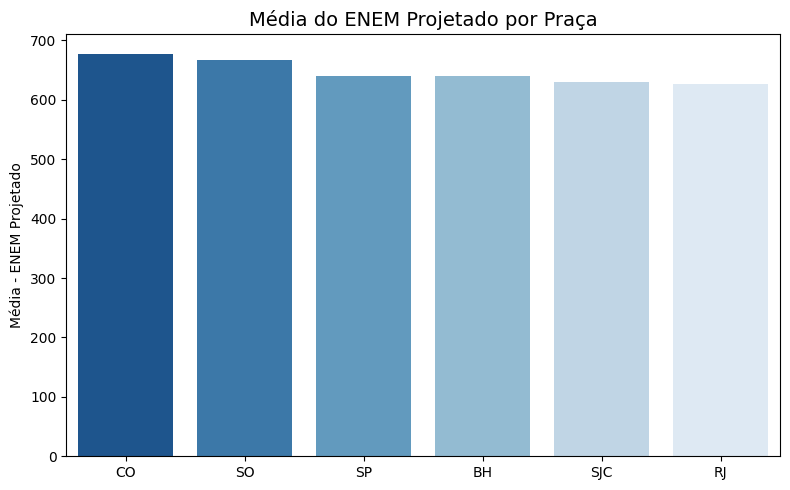

In [ ]:
#SP - SÃO PAULO, BH - BELO HORIZONTE, RJ - RIO DE JANEIRO
#CO - COTIA, SJC - SÃO JOSÉ DOS CAMPOS, SO - SOROCABA

#Exibe o gráfico
media_por_praca_limpa = df.groupby('PRACA_LIMPA')['ENEM_Projetado'].mean().reset_index()
media_por_praca_limpa = media_por_praca_limpa.sort_values(by='ENEM_Projetado', ascending=False)

plt.figure(figsize=(8, 5)) 
# É ajustado a paleta de cores para tons de azul e inverte a ordem para destacar as praças com maiores médias
sns.barplot(data=media_por_praca_limpa, 
            x='PRACA_LIMPA', 
            y='ENEM_Projetado', 
            hue='PRACA_LIMPA', 
            palette='Blues_r', 
            legend=False)

plt.title('Média do ENEM Projetado por Praça', fontsize=14)
plt.ylabel('Média - ENEM Projetado')
plt.xlabel('') 
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show();

Conforme o gráfico acima, a praça com maior média de ENEM PROJETADO em 2023 é **Cotia (CO)**
---
### 3. Análise Exploratória e Ações Sugeridas
Para extrair insights práticos que gerem valor, cruzamos o desempenho médio de cada Praça por Área do Conhecimento.

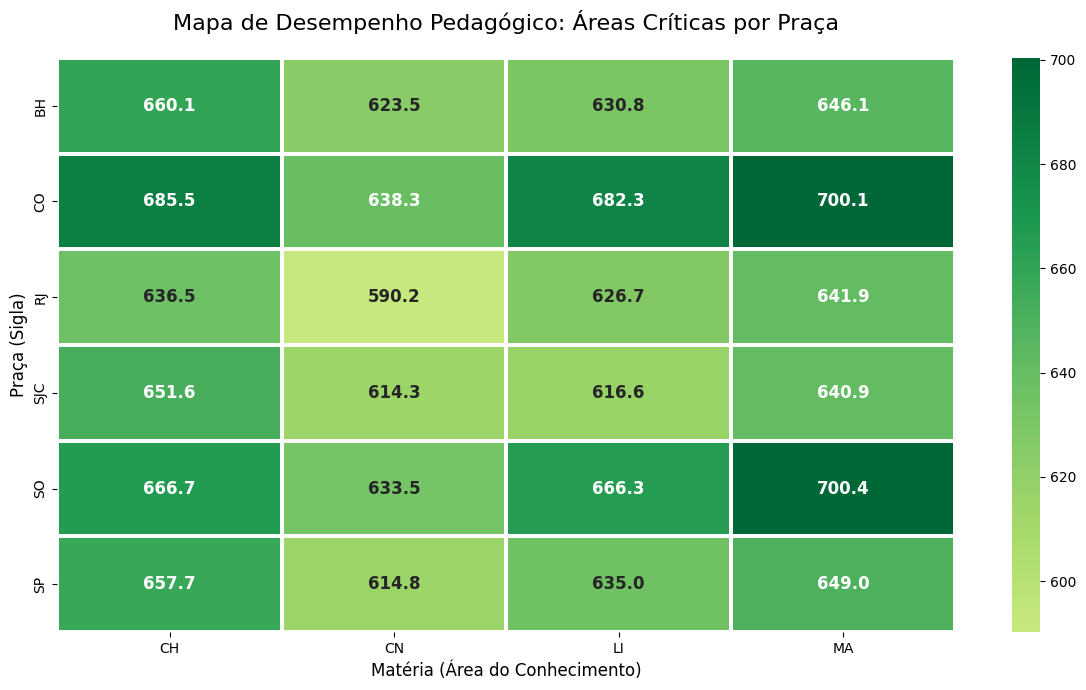

In [ ]:
#SP - SÃO PAULO, BH - BELO HORIZONTE, RJ - RIO DE JANEIRO
#CO - COTIA, SJC - SÃO JOSÉ DOS CAMPOS, SO - SOROCABA

# Recriando a tabela do heatmap com as siglas
media_praca_area = df.pivot_table(index='PRACA_LIMPA', columns='ÁREA', values='ENEM_Projetado', aggfunc='mean')

plt.figure(figsize=(12, 7))

# Heatmap com siglas e cores ajustadas
sns.heatmap(media_praca_area, 
            annot=True, 
            cmap='RdYlGn', 
            center=550,  
            fmt=".1f", 
            linewidths=1.5, 
            linecolor='white',
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Mapa de Desempenho Pedagógico: Áreas Críticas por Praça', fontsize=16, pad=20)
plt.xlabel('Matéria (Área do Conhecimento)', fontsize=12)
plt.ylabel('Praça (Sigla)', fontsize=12)
plt.tight_layout()
plt.show();

#### Conclusões Estratégicas para o Time:

1. **Situação Crítica em Matemática (SJC e RJ):** Os dados revelam que a praça de **São José dos Campos (SJC)** apresenta a menor média em Matemática (MA) de toda a rede, seguida de perto pelo **Rio de Janeiro (RJ)**. São Paulo (SP) também demonstra fragilidade em Ciências da Natureza (CN).
   * **Ação:** Implementar um plano de reforço acadêmico intensivo em disciplinas de exatas com foco prioritário em SJC e RJ, onde o sinal de alerta é mais severo.


2. **Destaque de Performance (Cotia - CO):** A praça de **Cotia** apresenta o melhor desempenho médio da rede em 2023, liderando com as maiores notas em praticamente todas as áreas do conhecimento.
   * **Ação:** Identificar quais práticas pedagógicas estão sendo aplicadas em Cotia que podem ser escaladas para as outras unidades da rede.